In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [28]:
df = pd.read_csv(
    "../data/processed/Student_Attendance_Summary.csv"
)

df.head()

,Student_ID,Student_Name,College_Name,Total_Sessions,Sessions_Attended,Average_Attendance_Minutes,Attendance_Percentage,Attendance_Std,Consistency_Score,Domain_Participation_Count,Engagement_Score,Eligible
0,ST0001,Sai Reddy,VIT AP,40,37,48.70,92.5,14.72,85.28,1,76.83,1
1,ST0002,Rohit Gupta,Narasaraopeta Engg,40,30,40.98,75.0,24.18,75.82,1,65.25,0
2,ST0003,Harsha Kumar,VNR VJIET,40,28,37.38,70.0,25.01,74.99,1,62.50,0
3,ST0004,Praveen Gupta,Gudlavalleru Engg,40,33,43.48,82.5,20.68,79.32,1,70.05,1
4,ST0005,Varun Patel,Andhra Loyola,40,27,35.90,67.5,25.50,74.50,1,61.10,0


In [29]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 980
Columns : 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  980 non-null    object 
 1   Student_Name                980 non-null    object 
 2   College_Name                980 non-null    object 
 3   Total_Sessions              980 non-null    int64  
 4   Sessions_Attended           980 non-null    int64  
 5   Average_Attendance_Minutes  980 non-null    float64
 6   Attendance_Percentage       980 non-null    float64
 7   Attendance_Std              980 non-null    float64
 8   Consistency_Score           980 non-null    float64
 9   Domain_Participation_Count  980 non-null    int64  
 10  Engagement_Score            980 non-null    float64
 11  Eligible                    980 non-null    int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 92.0+ KB


In [30]:
df.describe(include='all')

,Student_ID,Student_Name,College_Name,Total_Sessions,Sessions_Attended,Average_Attendance_Minutes,Attendance_Percentage,Attendance_Std,Consistency_Score,Domain_Participation_Count,Engagement_Score,Eligible
count,980,980,980,980.0,980.000000,980.000000,980.000000,980.000000,980.000000,980.0,980.000000,980.000000
unique,980,179,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ST0001,Arjun Singh,Gudlavalleru Engg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,11,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,40.0,32.429592,42.589735,81.073980,18.342071,81.657929,1.0,70.034378,0.602041
std,NaN,NaN,NaN,0.0,5.930836,7.790701,14.827089,7.317350,7.317350,0.0,9.406328,0.489727
min,NaN,NaN,NaN,40.0,7.000000,9.280000,17.500000,3.470000,71.770000,1.0,37.610000,0.000000
25%,NaN,NaN,NaN,40.0,29.000000,37.542500,72.500000,14.437500,75.695000,1.0,63.802500,0.000000
50%,NaN,NaN,NaN,40.0,33.000000,43.580000,82.500000,20.635000,79.365000,1.0,70.050000,1.000000
75%,NaN,NaN,NaN,40.0,37.000000,49.162500,92.500000,24.305000,85.562500,1.0,76.920000,1.000000


In [31]:
df.isnull().sum()

Student_ID                    0
Student_Name                  0
College_Name                  0
Total_Sessions                0
Sessions_Attended             0
Average_Attendance_Minutes    0
Attendance_Percentage         0
Attendance_Std                0
Consistency_Score             0
Domain_Participation_Count    0
Engagement_Score              0
Eligible                      0
dtype: int64

In [32]:
print(df.columns.tolist())

['Student_ID', 'Student_Name', 'College_Name', 'Total_Sessions', 'Sessions_Attended', 'Average_Attendance_Minutes', 'Attendance_Percentage', 'Attendance_Std', 'Consistency_Score', 'Domain_Participation_Count', 'Engagement_Score', 'Eligible']


In [33]:
print(df.shape)
df.head()

(980, 12)


,Student_ID,Student_Name,College_Name,Total_Sessions,Sessions_Attended,Average_Attendance_Minutes,Attendance_Percentage,Attendance_Std,Consistency_Score,Domain_Participation_Count,Engagement_Score,Eligible
0,ST0001,Sai Reddy,VIT AP,40,37,48.70,92.5,14.72,85.28,1,76.83,1
1,ST0002,Rohit Gupta,Narasaraopeta Engg,40,30,40.98,75.0,24.18,75.82,1,65.25,0
2,ST0003,Harsha Kumar,VNR VJIET,40,28,37.38,70.0,25.01,74.99,1,62.50,0
3,ST0004,Praveen Gupta,Gudlavalleru Engg,40,33,43.48,82.5,20.68,79.32,1,70.05,1
4,ST0005,Varun Patel,Andhra Loyola,40,27,35.90,67.5,25.50,74.50,1,61.10,0


In [34]:
df['Certified'] = np.where(
    df['Attendance_Percentage'] >= 80,
    1,
    0
)

df['Certified'].value_counts()

Certified
1    590
0    390
Name: count, dtype: int64

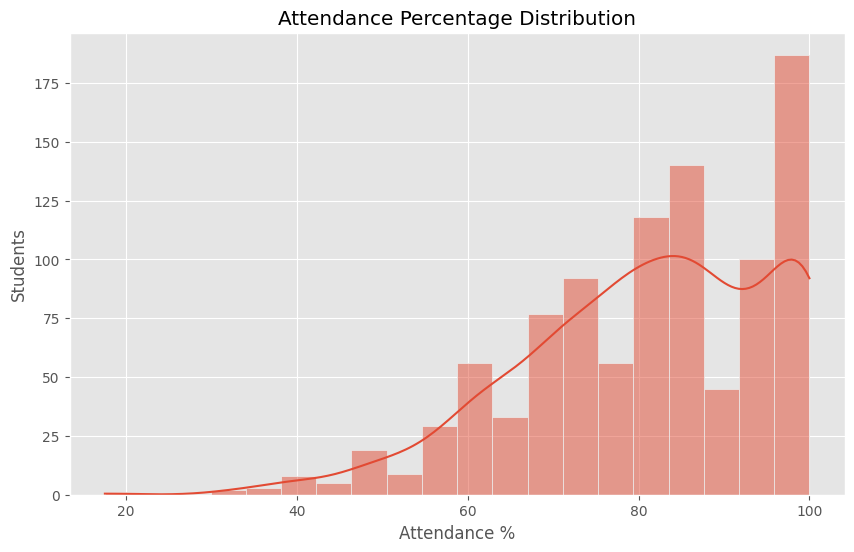

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Attendance_Percentage'],
    bins=20,
    kde=True
)

plt.title("Attendance Percentage Distribution")
plt.xlabel("Attendance %")
plt.ylabel("Students")

plt.savefig(
    "../visualizations/attendance_distribution.png"
)

plt.show()

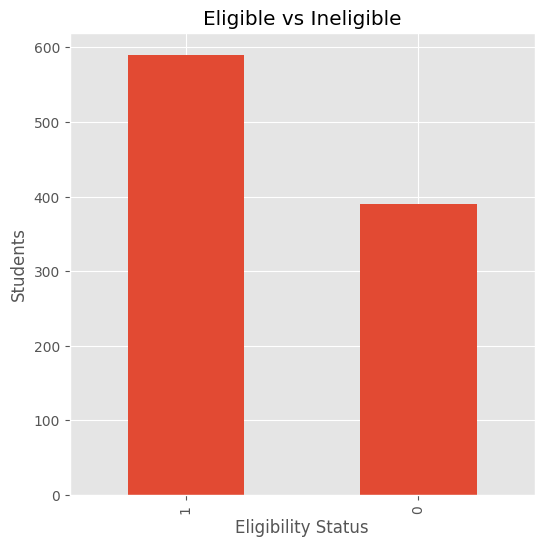

In [36]:
plt.figure(figsize=(6,6))

df['Eligible'].value_counts().plot(
    kind='bar'
)

plt.title("Eligible vs Ineligible")

plt.xlabel("Eligibility Status")
plt.ylabel("Students")

plt.savefig(
    "../visualizations/eligible_vs_ineligible.png"
)

plt.show()

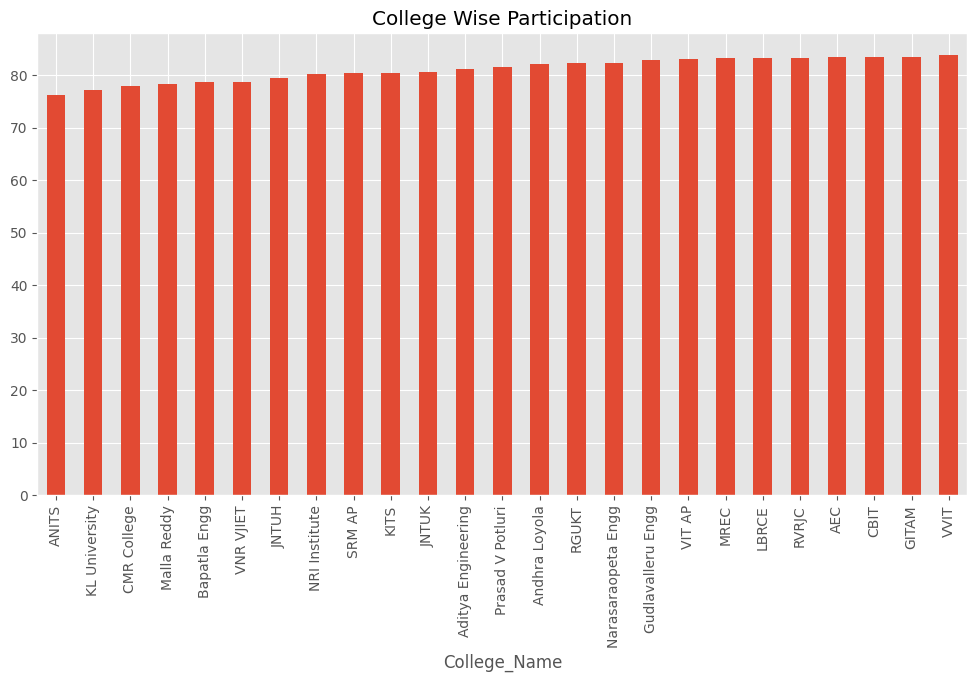

In [37]:
college_avg = df.groupby(
    'College_Name'
)['Attendance_Percentage'].mean()

college_avg.sort_values().plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("College Wise Participation")

plt.savefig(
    "../visualizations/college_wise_participation.png"
)

plt.show()

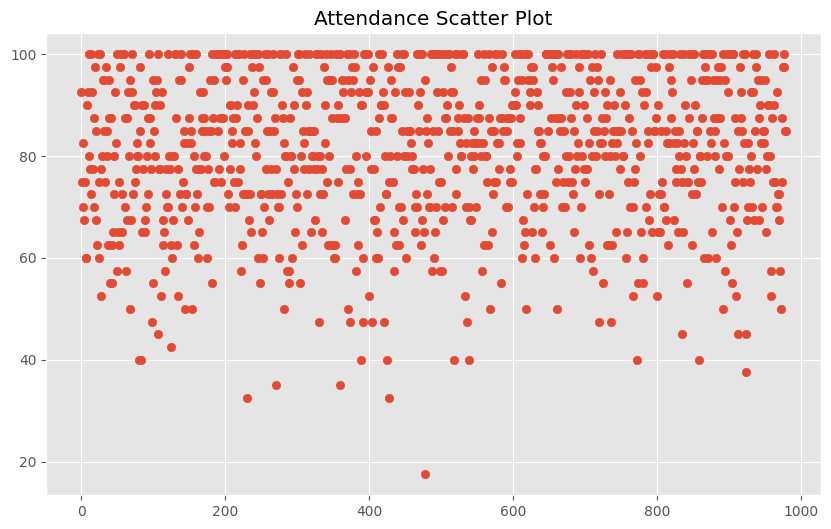

In [38]:
plt.figure(figsize=(10,6))

plt.scatter(
    range(len(df)),
    df['Attendance_Percentage']
)

plt.title("Attendance Scatter Plot")

plt.savefig(
    "../visualizations/attendance_scatter_plot.png"
)

plt.show()

In [39]:
df.head()
print(df.columns.tolist())

['Student_ID', 'Student_Name', 'College_Name', 'Total_Sessions', 'Sessions_Attended', 'Average_Attendance_Minutes', 'Attendance_Percentage', 'Attendance_Std', 'Consistency_Score', 'Domain_Participation_Count', 'Engagement_Score', 'Eligible', 'Certified']


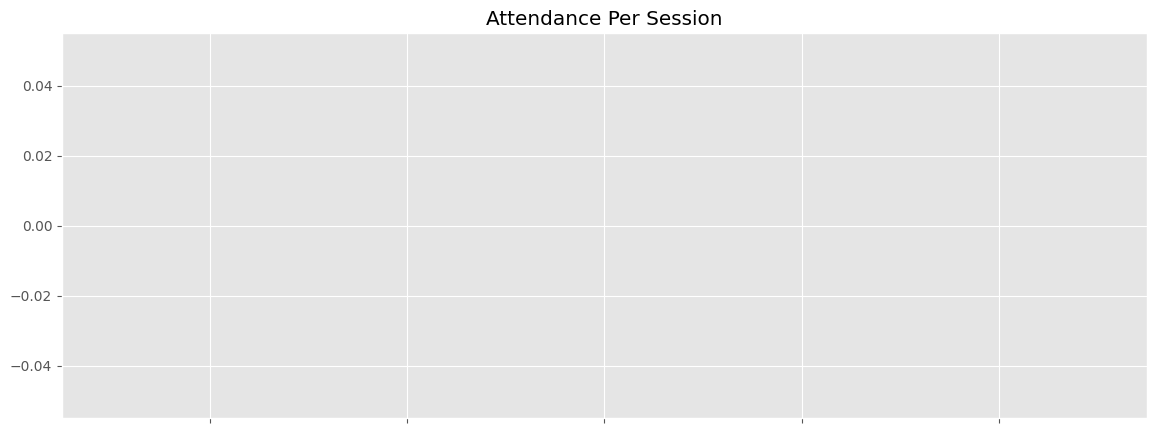

In [40]:
session_cols = [
    col for col in df.columns
    if "Session_" in col
]

attendance_per_session = (
    df[session_cols]
    .sum()
)

attendance_per_session.plot(
    figsize=(14,5)
)

plt.title("Attendance Per Session")
plt.show()

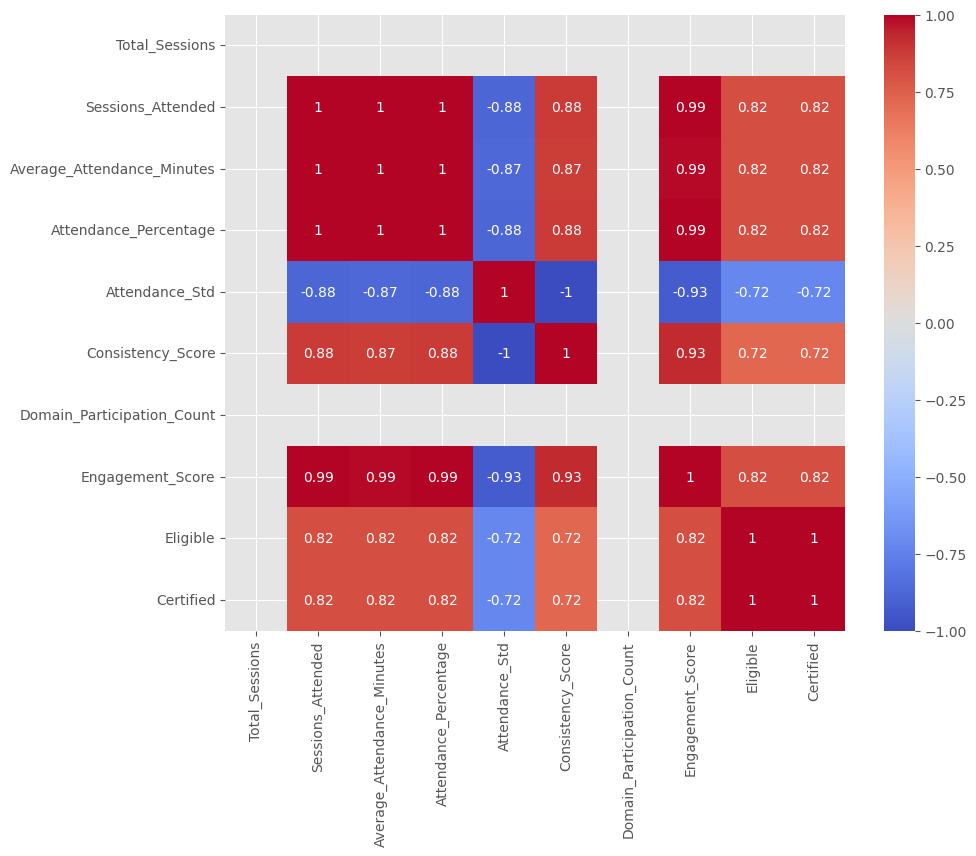

In [41]:
numeric_df = df.select_dtypes(
    include=np.number
)

corr = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()